In [ ]:
import pandas as pd
import seaborn as sns
from phyloDNN.seq_utils import rf_distance,squareform,njtree
from phyloDNN.bionj import BioNJ
from joblib import Parallel,delayed
import matplotlib.pyplot as plt
import numpy as np

# reimplement BIONJ

# Sanity check - compare HKY dist trees

In [3]:
data_dir = '/N/project/phyloML/data/phyloDNN/test/hky_60'

x=pd.read_pickle(f'{data_dir}/predictions_hkynet_e.pd.gz')
y=pd.read_csv(
    '/N/project/phyloML/data/phyloDNN/test/trees_60.tsv',
              sep='\s+',
              names=['filenames','true_trees'])
x = pd.merge(x,y)
x.describe()

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3092674/2762725701.py:5: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,filenames,names,predictions,trees,true_trees
count,1000,1000,1000,1000,1000
unique,1000,1,1000,1000,1000
top,135_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[1.8090651035308838, 0.810773491859436, 1.6161...","[&U] ((T43:0.008744184727022772,(T58:0.0040938...","(((T32:0.0414107,(T36:0.0783876,((((T6:0.00586..."
freq,1,1000,1,1,1


In [6]:
frob=[]
maxnorm=[]
drf_ml=[] # build NJ trees from ml distances
drf_pytorch=[]
for fn,df in x.set_index('filenames').iterrows():
    s=f'{data_dir}/{fn}_HKY.nj.mldist'
    mldist = pd.read_csv(s,sep='  +',skiprows=1,engine='python',header=None,index_col=0)
    mldist = pd.DataFrame(
        mldist[1].str.split(' ').tolist(),
        index=mldist.index,
        columns=mldist.index
    ).map(float).sort_index()
    mldist = mldist.reindex(sorted(mldist.columns), axis=1)
    bionj = BioNJ()
    # tree = njtree(mldist,mldist.index.tolist())
    tree = bionj.reconstruct_tree(mldist, mldist.index.tolist())
    drf_ml.append(
        rf_distance(tree,df.trees))
    pred = pd.DataFrame(squareform(df.predictions), 
                        index=df.names,
                        columns=df.names).sort_index()
    drf_pytorch.append( 
        bionj.reconstruct_tree(
            pred, pred.index.tolist())
    )
    frob.append(np.mean( (mldist-pred)**2 ).mean())
    maxnorm.append( np.max( np.abs(mldist-pred) ))
x['frobenious_norm'] = frob
x['max_norm'] = maxnorm
x['drf_bionj_new'] = drf_ml
x['torch_bionj_trees'] = drf_pytorch

In [7]:
x['bionj_trees'] = [open(f'{data_dir}/{fn}_HKY.nj.bionj').read() for fn in x.filenames]
x['ml_trees'] = [open(f'{data_dir}/{fn}_HKY.nj.treefile').read() for fn in x.filenames]

In [ ]:
with Parallel(8) as parallel:
    x['drf_pytorch'] = parallel(
     delayed(rf_distance)(*args) for args in x[['torch_bionj_trees','true_trees']].itertuples(False)
    )
    
    x['drf_bionj'] = parallel(
     delayed(rf_distance)(*args) for args in x[['bionj_trees','true_trees']].itertuples(False)
    )
    
    x['drf_ml'] = parallel(
     delayed(rf_distance)(*args) for args in x[['ml_trees','true_trees']].itertuples(False)
    )

### Compute new BIONJ trees from ML dist

In [9]:
# x = pd.read_pickle(
#     f'{data_dir}/ml_distances.pd.gz'
# )

x.to_pickle(
    f'{data_dir}/ml_distances.pd.gz'
)
x.describe()

,frobenious_norm,max_norm,drf_bionj_new,drf_pytorch,drf_bionj,drf_ml
count,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.327798e+00,3.594398,0.194398,0.213397,0.187271,0.186621
std,2.283713e+00,3.182000,0.194540,0.157804,0.137954,0.137084
min,4.701235e-10,0.000092,0.000000,0.000000,0.000000,0.000000
25%,2.318728e-04,0.090183,0.034483,0.086207,0.086207,0.086207
50%,6.601722e-02,5.935674,0.103448,0.155172,0.137931,0.137931
75%,1.725827e+00,6.678307,0.327586,0.327586,0.258621,0.258621
max,1.488462e+01,7.304077,0.775862,0.758621,0.834783,0.775862


In [11]:
x

,filenames,names,predictions,trees,true_trees,frobenious_norm,max_norm,drf_bionj_new,torch_bionj_trees,bionj_trees,ml_trees,drf_pytorch,drf_bionj,drf_ml
0,155_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[0.7287571430206299, 0.7561854720115662, 0.716...","[&U] ((T19:0.012271791248783455,(T45:0.0243773...","((T46:0.210333,(((((T48:0.00255154,T60:0.00194...",0.000408,0.164383,0.034483,"(T19:0.01193740,(T55:0.00093920,T38:0.00508568...","((((((T46:0.216818,((((T48:0.0021674777,T60:0....","(T46:0.2278886831,((((T48:0.0010031123,T60:0.0...",0.068966,0.068966,0.068966
1,549_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[0.7976894974708557, 1.8471776247024536, 1.110...","[&U] (T20:0.11116305280909536,(((T37:0.2042743...","(((((((T47:0.151541,T37:0.190064):0.573571,((T...",0.063393,5.107688,0.103448,"((T27:0.33763147,T20:0.22604745):0.00533709,((...","((((((((((T47:0.15230133,T37:0.19808687):0.506...","(T47:0.1763444345,T37:0.1755805702,((((T43:0.0...",0.155172,0.137931,0.137931
2,620_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[1.5747735500335693, 1.0363487005233765, 0.423...","[&U] ((T4:0.16312500045654452,(((T37:0.0600173...","((T21:0.851124,(T31:0.698083,(T27:0.510282,((T...",0.601835,6.448797,0.379310,"(((T60:0.01888510,T14:0.01906462):0.28931248,(...","((((((((((T21:1.9496652,T27:-0.58358586):1.127...","(T21:0.8985053625,((T31:0.6823572393,(T56:0.00...",0.224138,0.206897,0.206897
3,202_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[1.3663798570632935, 0.8851819634437561, 0.515...","[&U] (T19:0.001993758024673462,((T60:0.0019065...","((((T58:0.231742,(T56:0.100205,(T11:0.0646717,...",0.008599,0.775600,0.051724,"(T19:0.00402121,((((((T8:0.03426494,T55:0.0208...","((((((((T58:0.21715534,(T56:0.11581741,(T11:0....","(T58:0.2043900190,(T56:0.1130166782,(T11:0.058...",0.051724,0.051724,0.051724
4,82_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[2.370438575744629, 1.3593090772628784, 1.9797...","[&U] (((T28:0.027609426923013936,T58:0.0349303...","((((((T45:0.0300733,T7:0.0176993):0.0196564,(T...",0.486967,6.453086,0.068966,"((T15:0.07715696,T13:0.10958267):0.05063257,((...","((((((((((T45:0.022061864,T7:0.025481174):0.01...","(T45:0.0341862514,T7:0.0138842658,((T19:0.0804...",0.103448,0.103448,0.103448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,589_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[1.7249641418457031, 1.6215883493423462, 1.978...","[&U] (T13:0.1663103081386948,((T50:0.075325254...","((((((((T50:0.0832092,(T24:0.0658738,(T2:0.083...",0.003290,0.412972,0.086207,"(((T50:0.07605465,(((T39:0.04918957,T35:0.0480...","((T50:0.074605525,(T24:0.064712472,(T2:0.10294...","(T50:0.0816058211,(T24:0.0611696282,(T2:0.0998...",0.086207,0.103448,0.103448
996,504_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[2.2285237312316895, 1.3495392799377441, 9.0, ...","[&U] ((T55:0.0845127463218431,(T34:0.007703228...","(((((T56:0.685861,((((T8:0.0811561,(T34:0.0051...",1.131016,6.263941,0.327586,"((T55:0.08356297,(T34:0.00767106,T29:0.0023965...","(((((T56:0.59526551,((((T12:0.28901729,T10:0.2...","(T56:0.6307065073,(((T8:0.0518342602,((T34:0.0...",0.465517,0.396552,0.396552
997,768_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[9.0, 9.0, 0.9522113800048828, 9.0, 9.0, 0.860...","[&U] (T58:0.009160875503973952,((T21:-0.027656...","(((T44:0.875065,((T54:0.186413,T14:0.169861):0...",8.574110,6.678928,0.568966,"((T58:0.00519090,(T4:0.01068485,T34:0.01785346...","(((((((((T44:0.96219516,(((T54:0.33977151,T14:...","(T44:0.9883195881,(((T54:0.1950451262,T14:0.16...",0.534483,0.379310,0.379310
998,76_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[0.5249066352844238, 0.6493276357650757, 0.659...","[&U] (T14:0.04002549118530273,((T4:0.064196999...","(((((T3:0.0506949,((T6:0.184938,T30:0.147344):...",0.004412,0.727405,0.137931,"((((T59:0.00203267,T43:0.00097636):0.00815400,...","((((((((((T3:0.05106136

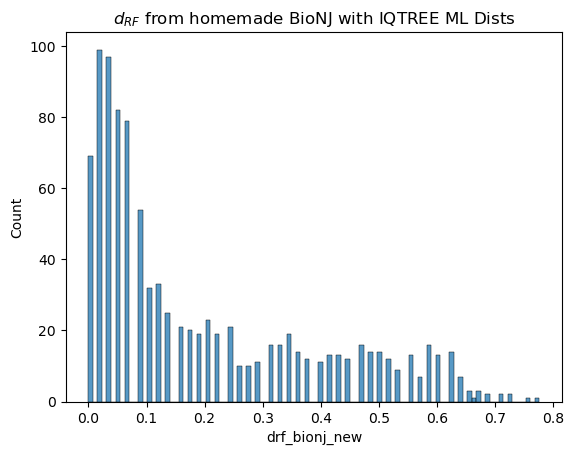

In [12]:
sns.histplot(x.drf_bionj_new,bins=100)
plt.title(r'$d_{RF}$ from homemade BioNJ with IQTREE ML Dists');

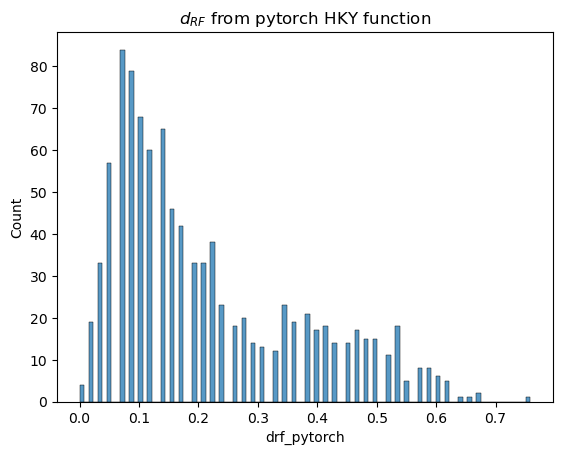

In [13]:
sns.histplot(x.drf_pytorch, bins=100)
plt.title(r'$d_{RF}$ from pytorch HKY function');

## Compare mldist from IQTREE HKY BIONJ to these distance matrices
For some reason dendropy NJ produces lower RF distance trees than IQTREE's BIONJ.

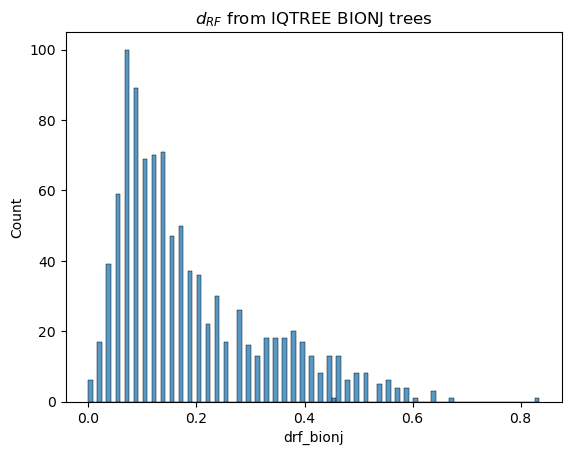

In [14]:
sns.histplot(x.drf_bionj, bins=100)
plt.title(r'$d_{RF}$ from IQTREE BIONJ trees');

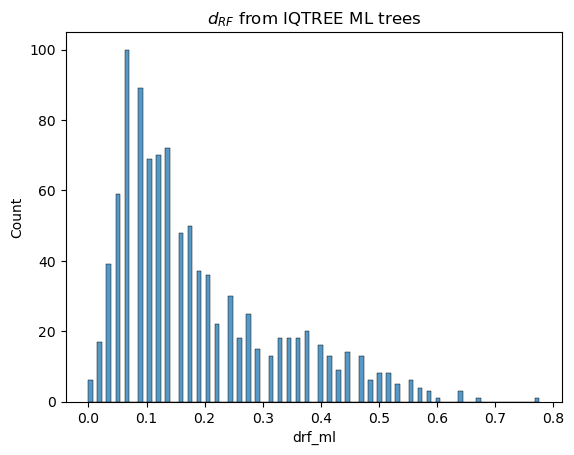

In [15]:
sns.histplot(x.drf_ml, bins=100)
plt.title(r'$d_{RF}$ from IQTREE ML trees');

In [16]:
sns.histplot(x.new_bionj_drf, bins=100)
plt.title(r'$d_{RF}$ from new BIONJ with ML dist');

AttributeError: 'DataFrame' object has no attribute 'new_bionj_drf'

### BIONJ parallel

In [98]:
import dendropy
import numpy as np
import math
from joblib import Parallel, delayed

def _calculate_q_value_parallel(i_idx, j_idx, current_distances_np, r_values_np, N):
    """
    Helper function for parallel Q_ij calculation.
    Args:
        i_idx (int): Index of the first node.
        j_idx (int): Index of the second node.
        current_distances_np (numpy.ndarray): The current distance matrix.
        r_values_np (numpy.ndarray): The current r_values array.
        N (int): The current number of active nodes.
    Returns:
        tuple: (Q_ij value, i_idx, j_idx)
    """
    d_ij = current_distances_np[i_idx, j_idx]
    divisor = (N - 2)
    # This check is technically redundant given the main loop condition (N > 2)
    # but good for robustness in a helper function.
    if divisor == 0:
        return float('inf'), i_idx, j_idx
    q_ij = d_ij - (r_values_np[i_idx] + r_values_np[j_idx]) / divisor
    return q_ij, i_idx, j_idx

def bionj_optimized(taxon_names, distance_matrix, variance_matrix=None, n_jobs=-1, parallel_threshold=20):
    """
    Computes a phylogenetic tree using Gascuel's BIONJ algorithm, optimized
    with NumPy for vectorized operations and Joblib for potential parallelization.

    Args:
        taxon_names (list): A list of strings, where each string is a taxon name.
        distance_matrix (list of lists): A square, symmetric 2D list representing
                                         the pairwise evolutionary distances between taxa.
        variance_matrix (list of lists, optional): A square, symmetric 2D list
                                                   representing the variances of the
                                                   pairwise distances. If None,
                                                   all variances are assumed to be 1.0.
        n_jobs (int, optional): Number of jobs to run in parallel for Q_ij calculation.
                                -1 means using all available CPU cores. Default is -1.
        parallel_threshold (int, optional): Minimum number of active nodes (N) for
                                            Joblib parallelization to be used for Q_ij calculation.
                                            For N below this, a sequential loop is used. Default is 20.

    Returns:
        dendropy.Tree: A DendroPy Tree object representing the inferred phylogeny.

    Raises:
        ValueError: If input dimensions are incorrect or less than two taxa are provided.
    """
    num_taxa = len(taxon_names)
    if num_taxa < 2:
        raise ValueError("BIONJ algorithm requires at least two taxa.")
    if len(distance_matrix) != num_taxa or any(len(row) != num_taxa for row in distance_matrix):
        raise ValueError("Distance matrix must be square and its dimensions must match the number of taxa.")
    if variance_matrix is not None and (len(variance_matrix) != num_taxa or any(len(row) != num_taxa for row in variance_matrix)):
        raise ValueError("Variance matrix must be square and its dimensions must match the number of taxa.")

    # 1. Initialization
    taxon_namespace = dendropy.TaxonNamespace(taxon_names)

    # List of active nodes. The index in this list corresponds to the index
    # in the current_distances and current_variances NumPy arrays.
    active_nodes = []
    for i, name in enumerate(taxon_names):
        node = dendropy.Node(taxon=taxon_namespace.get_taxon(name))
        active_nodes.append(node)

    # Convert input matrices to NumPy arrays for efficient numerical operations
    current_distances = np.array(distance_matrix, dtype=float)
    if variance_matrix:
        current_variances = np.array(variance_matrix, dtype=float)
    else:
        # Default variance: constant 1.0 if not provided
        current_variances = np.ones((num_taxa, num_taxa), dtype=float)
        np.fill_diagonal(current_variances, 0.0) # Variances of self-distances are 0

    # Keep track of all nodes created (leaves and internal) to link them correctly
    all_nodes = list(active_nodes)
    next_internal_node_idx = 0 # Counter for naming internal nodes

    # 2. Iteration: Continue until only two active nodes remain
    while len(active_nodes) > 2:
        N = len(active_nodes) # Current number of active nodes

        # Calculate r_i for each active node i using NumPy vectorization
        # r_i is the sum of distances from node i to all other active nodes
        # Sum across rows (axis=1) to get r_i for each node
        r_values = np.sum(current_distances, axis=1)

        # Calculate Q_ij for all unique pairs (i, j) and find the pair with the minimum Q_ab
        min_q = float('inf')
        pair_to_join_indices = None # Store indices (idx_a, idx_b)

        # Decide whether to use parallel processing based on the number of active nodes
        if N > parallel_threshold:
            # Use joblib.Parallel to compute Q_ij values for all pairs in parallel
            results = Parallel(n_jobs=n_jobs)(
                delayed(_calculate_q_value_parallel)(i_idx, j_idx, current_distances, r_values, N)
                for i_idx in range(N) for j_idx in range(i_idx + 1, N)
            )
            # Find the minimum Q_ij from the parallel results
            for q_ij, i_idx, j_idx in results:
                if q_ij < min_q:
                    min_q = q_ij
                    pair_to_join_indices = (i_idx, j_idx)
        else:
            # For smaller N, the overhead of parallelization might negate benefits,
            # so a direct sequential loop is more efficient.
            for i_idx in range(N):
                for j_idx in range(i_idx + 1, N):
                    d_ij = current_distances[i_idx, j_idx]
                    q_ij = d_ij - (r_values[i_idx] + r_values[j_idx]) / (N - 2)
                    if q_ij < min_q:
                        min_q = q_ij
                        pair_to_join_indices = (i_idx, j_idx)

        # Extract the two nodes to be joined and their original indices
        idx_a, idx_b = pair_to_join_indices
        a = active_nodes[idx_a]
        b = active_nodes[idx_b]

        # Create a new internal node 'u' that will be the parent of 'a' and 'b'
        u = dendropy.Node(label=f"internal_{next_internal_node_idx}")
        next_internal_node_idx += 1
        all_nodes.append(u) # Add the new internal node to the list of all nodes

        # Calculate branch lengths from the new node 'u' to its children 'a' and 'b'
        d_ab = current_distances[idx_a, idx_b]

        d_au = (d_ab + (r_values[idx_a] - r_values[idx_b]) / (N - 2)) / 2
        d_bu = (d_ab + (r_values[idx_b] - r_values[idx_a]) / (N - 2)) / 2

        # Assign branch lengths, ensuring they are non-negative
        a.edge_length = max(0.0, d_au)
        b.edge_length = max(0.0, d_bu)

        # Attach 'a' and 'b' as children of 'u'
        u.add_child(a)
        u.add_child(b)

        # Update distances and variances for the new node 'u' with respect to all other active nodes 'k'
        # This involves dynamically resizing NumPy matrices.

        # Get the variance of the joined pair (a,b)
        v_ab = current_variances[idx_a, idx_b]

        # Calculate new distances and variances for 'u' to all 'k' (including a and b temporarily)
        d_u_to_all_k_full = (current_distances[idx_a, :] + current_distances[idx_b, :] - d_ab) / 2
        v_u_to_all_k_full = (current_variances[idx_a, :] + current_variances[idx_b, :] + v_ab) / 2

        # Create a list of indices to remove (idx_a and idx_b)
        # Sort them in descending order to prevent index shifts during pop() operations
        indices_to_remove_from_active_nodes = sorted([idx_a, idx_b], reverse=True)

        # Remove rows and columns corresponding to 'a' and 'b' from the matrices
        # np.delete handles sorted indices correctly.
        temp_distances = np.delete(current_distances, indices_to_remove_from_active_nodes, axis=0)
        temp_distances = np.delete(temp_distances, indices_to_remove_from_active_nodes, axis=1)

        temp_variances = np.delete(current_variances, indices_to_remove_from_active_nodes, axis=0)
        temp_variances = np.delete(temp_variances, indices_to_remove_from_active_nodes, axis=1)

        # Filter d_u_to_all_k_full and v_u_to_all_k_full to exclude a and b
        # This creates the row/column for 'u' relative to the remaining nodes
        d_u_row_filtered = np.delete(d_u_to_all_k_full, indices_to_remove_from_active_nodes)
        v_u_row_filtered = np.delete(v_u_to_all_k_full, indices_to_remove_from_active_nodes)

        # Insert the new row/column for 'u' at the end of the matrices
        # The new size will be (N-1) x (N-1)
        # We insert at index (N-2) because the matrix is now (N-2) x (N-2) before insertion
        # and the new row/column will be the last one.
        new_N = N - 1 # New number of active nodes

        current_distances = np.insert(temp_distances, new_N - 1, d_u_row_filtered, axis=0)
        current_distances = np.insert(current_distances, new_N - 1, d_u_row_filtered, axis=1)
        current_distances[new_N - 1, new_N - 1] = 0.0 # Distance from u to u is 0

        current_variances = np.insert(temp_variances, new_N - 1, v_u_row_filtered, axis=0)
        current_variances = np.insert(current_variances, new_N - 1, v_u_row_filtered, axis=1)
        current_variances[new_N - 1, new_N - 1] = 0.0 # Variance from u to u is 0

        # Update the active_nodes list
        # Remove 'a' and 'b', then add 'u'
        # Remove in descending order of index to prevent index shifts for subsequent removals.
        for idx in indices_to_remove_from_active_nodes:
            active_nodes.pop(idx)
        active_nodes.append(u)


In [ ]:

drf_ml=[]
for fn,df in x.set_index('filenames').iterrows():
    s=f'{data_dir}/{fn}_HKY.nj.mldist'
    mldist = pd.read_csv(s,sep='  +',skiprows=1,engine='python',header=None,index_col=0)
    mldist = pd.DataFrame(mldist[1].str.split(' ').tolist(),index=mldist.index,columns=mldist.index).map(float).sort_index()
    mldist = mldist.reindex(sorted(mldist.columns), axis=1)
    tree = bionj_optimized(taxon_names= mldist.index.tolist(), distance_matrix = mldist.values,n_jobs=8)
    drf_ml.append(rf_distance(tree,df.trees))
x['new_bionj_drf_opt'] = drf_ml

In [ ]:

def nj_tree(self,
        is_weighted_edge_distances=True,
        tree_factory=None,
        ):
    """
    Returns an Neighbor-Joining (NJ) tree based on the distances in the matrix.

    Calculates and returns a tree under the Neighbor-Joining algorithm of
    Saitou and Nei (1987) for the data in the matrix.

    Parameters
    ----------
    is_weighted_edge_distances: bool
        If ``True`` then edge lengths will be considered for distances.
        Otherwise, just the number of edges.

    Returns
    -------
    t : |Tree|
        A |Tree| instance corresponding to the Neighbor-Joining (NJ) tree
        for this data.

    Examples
    --------

    ::

        import dendropy

        # Read data from a CSV file into a PhylogeneticDistanceMatrix
        # object
        with open("distance_matrix.csv") as src:
            pdm = dendropy.PhylogeneticDistanceMatrix.from_csv(
                    src,
                    is_first_row_column_names=True,
                    is_first_column_row_names=True,
                    is_allow_new_taxa=True,
                    delimiter=",",
                    )

        # Calculate the tree
        nj_tree = pdm.nj_tree()

        # Print it
        print(nj_tree.as_string("nexus"))


    References
    ----------
    Saitou, N. and Nei, M. (1987) The neighbor-joining method: a new method
    for reconstructing phylogenetic trees. Molecular Biology and Evolution,
    4: 406-425.

    """

    if is_weighted_edge_distances:
        original_dmatrix = self._taxon_phylogenetic_distances
    else:
        original_dmatrix = self._taxon_phylogenetic_path_steps
    if tree_factory is None:
        tree_factory = dendropy.Tree
    tree = tree_factory(taxon_namespace=self.taxon_namespace)
    tree.is_rooted = False

    # initialize node pool
    node_pool = []
    for t1 in self._mapped_taxa:
        nd = tree.node_factory()
        nd.taxon = t1
        nd._nj_distances = {}
        nd._nj_variances = {}
        node_pool.append(nd)

    # initialize factor
    n = len(self._mapped_taxa)

    # cache calculations
    for nd1 in node_pool:
        nd1._nj_xsub = 0.0
        for nd2 in node_pool:
            if nd1 is nd2:
                continue
            d = original_dmatrix[nd1.taxon][nd2.taxon]
            nd1._nj_distances[nd2] = d
            nd1._nj_variances[nd2] = d
            nd1._nj_xsub += d

    while n > 1:

        # calculate the Q-matrix
        min_q = None
        nodes_to_join = None
        for idx1, nd1 in enumerate(node_pool[:-1]):
            for idx2, nd2 in enumerate(node_pool[idx1+1:]):
                v1 = (n - 2) * nd1._nj_distances[nd2]
                qvalue = v1 - nd1._nj_xsub - nd2._nj_xsub
                if min_q is None or qvalue < min_q:
                    min_q = qvalue
                    nodes_to_join = (nd1, nd2)

        # create the new node
        new_node = tree.node_factory()

        # attach it to the tree
        for node_to_join in nodes_to_join:
            new_node.add_child(node_to_join)
            node_pool.remove(node_to_join)

        # calculate the distances for the new node
        new_node._nj_distances = {}
        new_node._nj_xsub = 0.0
        for node in node_pool:
            # actual node-to-node distances
            v1 = 0.0
            for node_to_join in nodes_to_join:
                v1 += node._nj_distances[node_to_join]
            v3 = nodes_to_join[0]._nj_distances[nodes_to_join[1]]
            dist = 0.5 * (v1 - v3)
            new_node._nj_distances[node] = dist
            node._nj_distances[new_node] = dist

            # Adjust/recalculate the values needed for the Q-matrix
            # calculations
            new_node._nj_xsub += dist
            node._nj_xsub += dist
            for node_to_join in nodes_to_join:
                node._nj_xsub -= node_to_join._nj_distances[node]

        # calculate the branch lengths
        if n > 2:
            v1 = 0.5 * nodes_to_join[0]._nj_distances[nodes_to_join[1]]
            v4  = 1.0/(2*(n-2)) * (nodes_to_join[0]._nj_xsub - nodes_to_join[1]._nj_xsub)
            delta_f = v1 + v4
            delta_g = nodes_to_join[0]._nj_distances[nodes_to_join[1]] - delta_f
            nodes_to_join[0].edge.length = delta_f
            nodes_to_join[1].edge.length = delta_g
        else:
            d = nodes_to_join[0]._nj_distances[nodes_to_join[1]]
            nodes_to_join[0].edge.length = d / 2
            nodes_to_join[1].edge.length = d / 2

        # clean up
        for node_to_join in nodes_to_join:
            del node_to_join._nj_distances
            del node_to_join._nj_xsub

        # add the new node to the pool of nodes
        node_pool.append(new_node)

        # adjust count
        n -= 1

    tree.seed_node = node_pool[0]
    del tree.seed_node._nj_distances
    del tree.seed_node._nj_xsub
    return tree

In [30]:
from dendropy import PhylogeneticDistanceMatrix
# pdm = PhylogeneticDistanceMatrix(x.iloc[0].)
x

,filenames,names,predictions,trees,true_trees,frobenious_norm,max_norm,drf_nj,bionj_trees,ml_trees,drf_pytorch,drf_bionj,drf_ml,new_bionj_drf
0,155_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[0.7287572622299194, 0.7561854720115662, 0.716...","[&U] (T38:0.002556600303344726,(T55:0.00091168...","((T46:0.210333,(((((T48:0.00255154,T60:0.00194...",4.080982e-04,1.643831e-01,0.000000,"((((((T46:0.216818,((((T48:0.0021674777,T60:0....","(T46:0.2278886831,((((T48:0.0010031123,T60:0.0...",0.051724,0.068966,0.068966,0.258621
1,549_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[0.7976894974708557, 1.84717857837677, 1.11016...","[&U] ((T36:0.008678528209278672,T2:0.031372071...","(((((((T47:0.151541,T37:0.190064):0.573571,((T...",5.731576e-02,3.892312e+00,0.362069,"((((((((((T47:0.15230133,T37:0.19808687):0.506...","(T47:0.1763444345,T37:0.1755805702,((((T43:0.0...",0.293103,0.137931,0.137931,0.534483
2,620_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[1.5747737884521484, 1.036348819732666, 0.4235...","[&U] ((T24:0.343720585,T5:0.343720585):0.0,(T3...","((T21:0.851124,(T31:0.698083,(T27:0.510282,((T...",1.929868e+74,3.402823e+38,0.982759,"((((((((((T21:1.9496652,T27:-0.58358586):1.127...","(T21:0.8985053625,((T31:0.6823572393,(T56:0.00...",0.982759,0.206897,0.206897,0.965517
3,202_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[1.366380214691162, 0.8851819634437561, 0.5158...","[&U] (T19:0.001993757883529663,((T60:0.0019065...","((((T58:0.231742,(T56:0.100205,(T11:0.0646717,...",8.598803e-03,7.755995e-01,0.017241,"((((((((T58:0.21715534,(T56:0.11581741,(T11:0....","(T58:0.2043900190,(T56:0.1130166782,(T11:0.058...",0.086207,0.051724,0.051724,0.396552
4,82_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[2.3704402446746826, 1.3593090772628784, 1.979...","[&U] ((T55:-1.1805915503486671e+21,(T9:-2.3611...","((((((T45:0.0300733,T7:0.0176993):0.0196564,(T...",6.432893e+73,3.402823e+38,0.982759,"((((((((((T45:0.022061864,T7:0.025481174):0.01...","(T45:0.0341862514,T7:0.0138842658,((T19:0.0804...",0.982759,0.103448,0.103448,0.982759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,589_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[1.7249643802642822, 1.6215888261795044, 1.978...","[&U] (T13:0.16631032018512726,((T50:0.07532524...","((((((((T50:0.0832092,(T24:0.0658738,(T2:0.083...",3.290393e-03,4.129718e-01,0.051724,"((T50:0.074605525,(T24:0.064712472,(T2:0.10294...","(T50:0.0816058211,(T24:0.0611696282,(T2:0.0998...",0.068966,0.103448,0.103448,0.275862
996,504_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[2.2285242080688477, 1.3495392799377441, 0.0, ...","[&U] ((T59:-4.874662511389647e+24,(T39:-8.9174...","(((((T56:0.685861,((((T8:0.0811561,(T34:0.0051...",1.672552e+75,3.402823e+38,0.982759,"(((((T56:0.59526551,((((T12:0.28901729,T10:0.2...","(T56:0.6307065073,(((T8:0.0518342602,((T34:0.0...",0.982759,0.396552,0.396552,0.982759
997,768_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[0.0, 0.0, 0.9522116184234619, 0.0, 0.0, 0.860...","[&U] ((T11:-9.444732402789337e+21,T47:9.444732...","(((T44:0.875065,((T54:0.186413,T14:0.169861):0...",6.432893e+74,3.402823e+38,0.982759,"(((((((((T44:0.96219516,(((T54:0.33977151,T14:...","(T44:0.9883195881,(((T54:0.1950451262,T14:0.16...",0.982759,0.379310,0.379310,0.982759
998,76_60_tips,"[T1, T10, T11, T12, T13, T14, T15, T16, T17, T...","[0.5249066352844238, 0.6493276953697205, 0.659...","[&U] (T14:0.040025492542724604,((T4:0.06419700...","(((((T3:0.0506949,((T6:0.184938,T30:0.147344):...",4.412091e-03,7.274049e-01,0.172414,"((((((((((T3:0.051061369,((T37:0.00020271365,T...","(T3:0.0556121181,((T6:0.1833129144,T30:0.13926...",0.241379,0.189655,0.189655,0.482759
